## Import Modules

In [36]:
import import_ipynb
data = __import__("01_data_exploration")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## The flood risk score

In [37]:
print(data.df["flood_risk_score"].describe())

count    25000.000000
mean        33.265946
std         14.783238
min          0.000000
25%         22.547500
50%         32.300000
75%         42.940000
max        100.000000
Name: flood_risk_score, dtype: float64


In [38]:
data.df['flood_occurrence_numeric'] = data.df['flood_occurrence_current_event'].map({'Yes': 1, 'No': 0})
correlation = data.df['flood_risk_score'].corr(data.df['flood_occurrence_numeric'])
print(f"Correlation: {correlation:.4f}")

Correlation: 0.5124


The correlation analysis produced a coefficient of 0.5124 between flood risk score and current flood occurrence. This indicates a moderate positive relationship, suggesting that locations with higher flood risk scores tend to have a greater likelihood of experiencing a current flood event. However, the correlation does not imply causation, and other environmental and geographic factors may contribute to flood occurrence.

Group your raw score into small intervals (e.g., width of 10) and calculate the actual flood probability per bin. Then group the bins into intuitive risk bands based on real-world probability.

In [39]:
bins = list(range(0, 101, 10))
data.df['score_bin'] = pd.cut(
    data.df['flood_risk_score'], bins=bins, include_lowest=True
)

prob_table = (
    data.df.groupby('score_bin', observed=False)['flood_occurrence_numeric']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'flood_probability'})
)
print(prob_table)

                count  flood_probability
score_bin                               
(-0.001, 10.0]   1096           0.000000
(10.0, 20.0]     3805           0.000000
(20.0, 30.0]     6054           0.000000
(30.0, 40.0]     6244           0.000000
(40.0, 50.0]     4407           0.159519
(50.0, 60.0]     2283           0.484450
(60.0, 70.0]      826           0.559322
(70.0, 80.0]      229           0.681223
(80.0, 90.0]       48           0.770833
(90.0, 100.0]       8           1.000000


In [40]:
def get_risk_level(score):
    if score <= 40: 
        return 'Low'
    elif score <= 60: 
        return 'Medium'
    else: 
        return 'High'

data.df['risk_level'] = data.df['flood_risk_score'].apply(get_risk_level)

### Plot histogram of flood_risk_score distribution

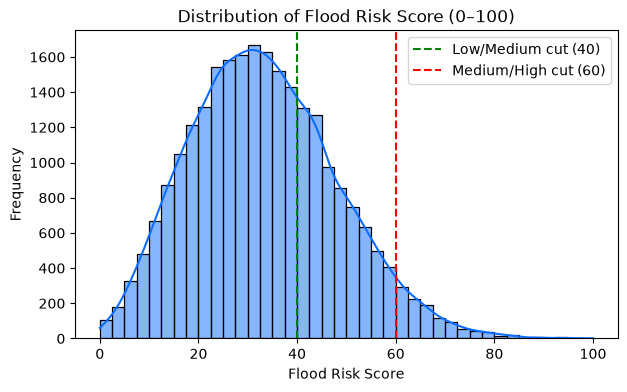

In [41]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data.df["flood_risk_score"], bins=40, kde=True, ax=ax, color="#0d6efd")

low_cut = 40
high_cut = 60

ax.axvline(low_cut, color="green", linestyle="--", label=f"Low/Medium cut ({low_cut})")
ax.axvline(high_cut, color="red", linestyle="--", label=f"Medium/High cut ({high_cut})")

ax.set_title("Distribution of Flood Risk Score (0–100)")
ax.set_xlabel("Flood Risk Score")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

In [42]:
counts = data.df["risk_level"].value_counts().reindex(["Low", "Medium", "High"])
print(counts)

risk_level
Low       17199
Medium     6690
High       1111
Name: count, dtype: int64


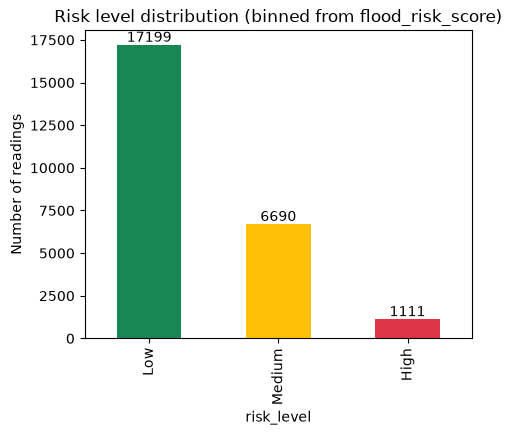

In [44]:
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", color=["#198754", "#ffc107", "#dc3545"], ax=ax)
ax.set_title("Risk level distribution (binned from flood_risk_score)")
ax.set_ylabel("Number of readings")
for container in ax.containers:
    ax.bar_label(container)
plt.show()